In [1]:
import wandb
from glob import glob
import pandas
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


# Results for PPO, PD Control and Baseline

In [21]:
mean = {"baseline": [], "PPO_rs25": [], "PPO_rs50": []}
std = {"baseline": [], "PPO_rs25": [], "PPO_rs50": []}
ra = [10000, 100000, 1000000, 5000000]

# read from csv
for method in mean.keys():
    for ra_elem in ra:
            if method == "baseline":
                path = f"res/{method}_ra{ra_elem}.csv"
            else:
                path = f"res/{method}_ra{ra_elem}_nusselt.csv"
            try:
                df = pandas.read_csv(path)

                # mean per episode
                df = df.groupby('episode').mean()
                mean[method].append(df["nusselt"].mean())
                std[method].append(df["nusselt"].std())
            except Exception as e:
                mean[method].append(0)
                std[method].append(0)

# # compute percentage
mean_percent = {"baseline": [], "PPO_rs25": [], "PPO_rs50": []}
std_percent = {"baseline": [], "PPO_rs25": [], "PPO_rs50": []}
for idx in range(len(mean["baseline"])):
    for method in mean.keys():
        b = mean["baseline"][idx]
        mean_percent[method].append(100 - (100 * mean[method][idx] / b))
        std_percent[method].append(100 * std[method][idx] / b)

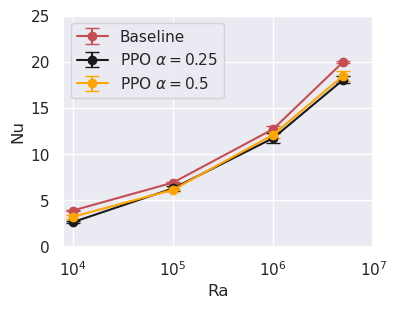

In [22]:
# plot
plt.figure(figsize=(4, 3))
sns.set_theme()

# x axis
plt.xlim(8000, 10000000)
plt.xticks(ticks=[10000, 100000, 1000000, 10000000], labels=["$10^4$","$10^5$","$10^6$", "$10^7$"])
plt.xlabel("Ra")
plt.xscale("log")

# y axis
plt.ylim(0, 25)
#plt.yscale("log")
plt.ylabel("Nu")

# plot data
plt.errorbar(ra, mean["baseline"], std["baseline"], linestyle="-", marker='o', color='r', capsize=5, label="Baseline")
plt.errorbar(ra, mean["PPO_rs25"], std["PPO_rs25"], linestyle="-", marker='o', color='k', capsize=5, label=r"PPO $\alpha=0.25$")
plt.errorbar(ra, mean["PPO_rs50"], std["PPO_rs50"], linestyle="-", marker='o', color='orange', capsize=5, label=r"PPO $\alpha=0.5$")
plt.legend()

plt.savefig("paperfigures/nusselt.svg", format="svg", bbox_inches="tight")
plt.show()

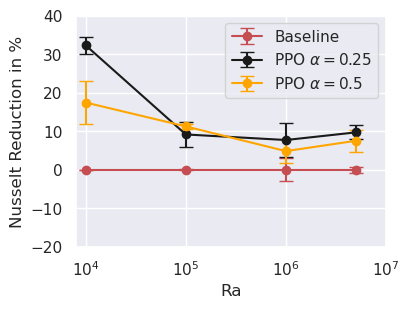

In [23]:
# plot
plt.figure(figsize=(4, 3))
sns.set_theme()

# x axis
plt.xlim(8000, 10000000)
plt.xticks(ticks=[10000, 100000, 1000000, 10000000], labels=["$10^4$","$10^5$","$10^6$", "$10^7$"])
plt.xlabel("Ra")
plt.xscale("log")

# y axis
plt.ylim(-20, 40)
plt.ylabel("Nusselt Reduction in %")

# plot data
plt.errorbar(ra, mean_percent["baseline"], std_percent["baseline"], linestyle="-", marker='o', color='r', capsize=5, label="Baseline")
plt.errorbar(ra, mean_percent["PPO_rs25"], std_percent["PPO_rs25"], linestyle="-", marker='o', color='k', capsize=5, label=r"PPO $\alpha=0.25$")
plt.errorbar(ra, mean_percent["PPO_rs50"], std_percent["PPO_rs50"], linestyle="-", marker='o', color='orange', capsize=5, label=r"PPO $\alpha=0.5$")
plt.legend()

plt.savefig("paperfigures/nusselt_reduction_percentage.svg", format="svg", bbox_inches="tight")
plt.show()

KeyError: 'ppo'

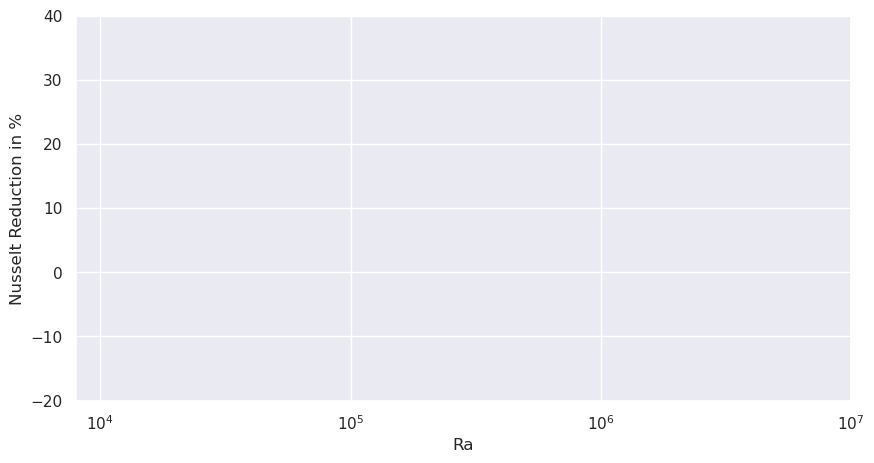

In [24]:
# NOTE: Figures for generalization to different ra, or percentage reaching one cell state, or time to reach one cell state.

# plot
plt.figure(figsize=(10, 5))
sns.set_theme()

# x axis
plt.xlim(8000, 10000000)
plt.xticks(ticks=[10000, 100000, 1000000, 10000000], labels=["$10^4$","$10^5$","$10^6$", "$10^7$"])
plt.xlabel("Ra")
plt.xscale("log")

# y axis
plt.ylim(-20, 40)
plt.ylabel("Nusselt Reduction in %")

# plot data
plt.errorbar(ra, mean_percent["ppo"], std_percent["ppo"], linestyle="-", marker='o', capsize=5, label="PPO")
plt.errorbar(ra, mean_percent["ppo_ra10000"], std_percent["ppo_ra10000"], linestyle="-", marker='o', capsize=5, label="PPO ra10000")
plt.errorbar(ra, mean_percent["ppo_ra100000"], std_percent["ppo_ra100000"], linestyle="-", marker='o', capsize=5, label="PPO ra100000")


plt.legend()
plt.show()

In [41]:
# What is the percentage of episodes that reach a one cell state?
# read from csv
csv_files_nors = [
        "PPO_rs0_ra10000_cell_dist.csv",
        "PPO_rs0_ra100000_cell_dist.csv",
        "PPO_rs0_ra1000000_cell_dist.csv",
        "PPO_rs0_ra5000000_cell_dist.csv"
        ]

csv_files_rs = [
     "PPO_rs25_ra10000_cell_dist.csv",
     "PPO_rs50_ra100000_cell_dist.csv",
     "PPO_rs50_ra1000000_cell_dist.csv",
     "PPO_rs50_ra5000000_cell_dist.csv"
     ]
ra = [10000, 100000, 1000000, 5000000]
percentages_one_cell_rs = []
thres = 0.8
nr_episodes = 20

def calculate_percentage(csv_files, thres, nr_episodes):
    percentages_one_cell_rs = []
    for i in range(len(csv_files)):
        path = f"res/{csv_files[i]}"
        try:
            df = pandas.read_csv(path)
            episodes_one_cell = 0
            for idx_group, episode_df in df.groupby('episode'):
                # if the episode already starts in one cell, we exclude it from the count
                if (episode_df.cell_dist.iloc[0:20] == 0).sum() >= 16:
                    continue
                # strategy: If among the last 10% of the episode, there is at least 80% with a cell distance of 0, then we consider it a one cell state.
                last_10_percent = int(0.1 * len(episode_df))
                episode_df.iloc[-last_10_percent:]
                one_cell_state = episode_df.iloc[-last_10_percent:].cell_dist == 0
                if one_cell_state.sum() / last_10_percent >= thres:
                    episodes_one_cell += 1
            percentages_one_cell_rs.append(episodes_one_cell / nr_episodes) 
            # print(f"Percentage of episodes that reach one cell state: {episodes_one_cell / nr_episodes}")
        except Exception as e:
            print(e)
    return percentages_one_cell_rs

percentages_one_cell_rs = calculate_percentage(csv_files_rs, thres, nr_episodes)
percentages_one_cell_nors = calculate_percentage(csv_files_nors, thres, nr_episodes)

In [42]:
percentages_one_cell_nors

[0.6, 0.1, 0.0, 0.0]

In [29]:
percentages_one_cell_rs

[1.0, 1.0, 0.2, 0.0]

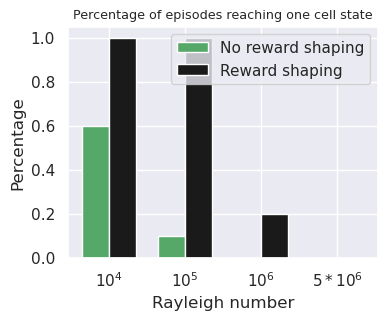

In [51]:
# Make a simple bar chart to show the result (with reward shaping and without reward shaping)
# Sample data
categories = [r'$10^4$', r'$10^5$', r'$10^6$', r'$5*10^6$']
values_group1 = percentages_one_cell_nors
values_group2 = percentages_one_cell_rs

x = np.arange(len(categories))  # x locations for groups
width = 0.35  # Width of bars

fig, ax = plt.subplots(figsize=(4, 3))

# Plot bars for both groups
bars1 = ax.bar(x - width/2, values_group1, width, color='g', label='No reward shaping')
bars2 = ax.bar(x + width/2, values_group2, width, color='k', label='Reward shaping')

# Labels and title
ax.set_xlabel("Rayleigh number")
ax.set_ylabel("Percentage")
ax.set_title("Percentage of episodes reaching one cell state", fontsize=9.2)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

plt.savefig("paperfigures/percentage_eps_onecell.svg", format="svg", bbox_inches="tight")

# Show the plot
plt.show()

In [78]:
# Last plot: time to reach one cell state
# Approach: What is the first window of 10% of the episode where the cell distance is 0 for at least 80% of the time?
# This makes sense only for ra=10000 and ra=100000
csv_files_rs = ["PPO_rs25_ra10000_cell_dist.csv", "PPO_rs50_ra100000_cell_dist.csv"]
csv_files_nors = ["PPO_rs0_ra10000_cell_dist.csv", "PPO_rs0_ra100000_cell_dist.csv"]
ra = [10000, 100000]   
thres = 0.8


def calculate_times_to_reach_one_cell(csv_files, thres):
    times_to_reach_one_cell = {}
    for file in csv_files:
        times_to_reach_one_cell[file] = []
    for file in csv_files:
        path = f"res/{file}"
        try:
            df = pandas.read_csv(path)
            for idx_group, episode_df in df.groupby('episode'):
                # first check if the episode reaches a one cell state
                last_10_percent = int(0.1 * len(episode_df))
                episode_df.iloc[-last_10_percent:]
                one_cell_state = episode_df.iloc[-last_10_percent:].cell_dist == 0
                if one_cell_state.sum() / last_10_percent < thres:
                    # print("episode does not go to a one cell state")
                    continue
                # so we only continue below if the episode reaches a one cell state, and we then check when it reaches it for the first time
                last_10_percent = int(0.1 * len(episode_df))
                for idx in range(0, len(episode_df) - last_10_percent):
                    subdf = episode_df.iloc[idx:idx+last_10_percent]
                    one_cell_state = subdf[subdf['cell_dist'] == 0]
                    if one_cell_state.shape[0] / last_10_percent >= thres:
                        times_to_reach_one_cell[file].append(one_cell_state.iloc[0].time)
                        break
        except Exception as e:
            print("An error occurred: ", e)
    return times_to_reach_one_cell

times_to_reach_one_cell_rs = calculate_times_to_reach_one_cell(csv_files_rs, thres)
times_to_reach_one_cell_nors = calculate_times_to_reach_one_cell(csv_files_nors, thres)

In [79]:
times_to_reach_one_cell_nors

{'PPO_rs0_ra10000_cell_dist.csv': [19.5,
  66.0,
  40.5,
  40.5,
  40.5,
  66.0,
  40.5,
  82.5,
  45.0,
  19.5,
  54.0,
  54.0],
 'PPO_rs0_ra100000_cell_dist.csv': [190.5, 190.5]}

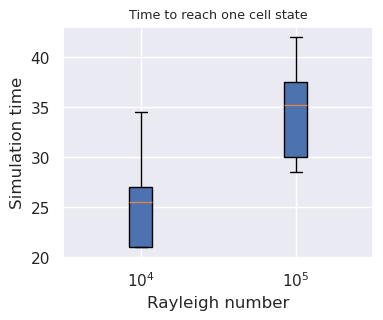

In [86]:
# Sample data for three categories
data = [times_to_reach_one_cell_rs["PPO_rs25_ra10000_cell_dist.csv"], times_to_reach_one_cell_rs["PPO_rs50_ra100000_cell_dist.csv"]]

categories = [r'$10^4$', r'$10^5$']

# Create the boxplot
fig, ax = plt.subplots(figsize=(4, 3))
ax.boxplot(data, labels=categories, patch_artist=True)

# Labels and title
ax.set_xlabel("Rayleigh number")
ax.set_ylabel("Simulation time")
ax.set_title("Time to reach one cell state", fontsize=9.2)

plt.savefig("paperfigures/time_eps_onecell.svg", format="svg", bbox_inches="tight")

# Show the plot
plt.show()

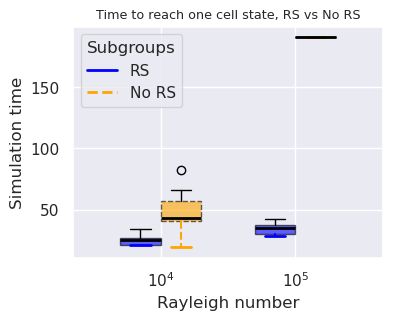

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data (replace with actual values)
data = [
    [times_to_reach_one_cell_rs["PPO_rs25_ra10000_cell_dist.csv"], 
     times_to_reach_one_cell_nors["PPO_rs0_ra10000_cell_dist.csv"]],  # Ra = 10^4
    
    [times_to_reach_one_cell_rs["PPO_rs50_ra100000_cell_dist.csv"], 
     times_to_reach_one_cell_nors["PPO_rs0_ra100000_cell_dist.csv"]]  # Ra = 10^5
]

categories = [r'$10^4$', r'$10^5$']  # Rayleigh numbers
group_labels = ['RS', 'No RS']  # Updated legend labels

# Define colors and styles
colors = ['blue', 'orange']
linestyles = ['solid', 'dashed']

# Create figure
fig, ax = plt.subplots(figsize=(4, 3))

# Set positions for grouping
num_groups = len(categories)
num_subgroups = len(data[0])
positions = np.arange(num_groups)  # Base positions
width = 0.3  # Width of each box

# Flatten the data and positions
all_data = [d for group in data for d in group]
all_positions = [p + (i - (num_subgroups - 1)/2) * width for p in positions for i in range(num_subgroups)]

# Create boxplot with different styles
boxplots = ax.boxplot(
    all_data, 
    positions=all_positions, 
    widths=width, 
    patch_artist=True  # Enables color filling
)

# Apply colors and styles
for i, (box, cap, whisker, median) in enumerate(zip(
    boxplots['boxes'], 
    boxplots['caps'][::2],  # Only start cap lines
    boxplots['whiskers'][::2],  # Only start whiskers
    boxplots['medians']
)):
    group_index = i % num_subgroups  # 0 or 1
    color = colors[group_index]
    
    box.set(facecolor=color, alpha=0.6, edgecolor='black', linestyle=linestyles[group_index])
    cap.set(color=color, linewidth=2)
    whisker.set(color=color, linewidth=1.5, linestyle=linestyles[group_index])
    median.set(color='black', linewidth=2)

# Adjust x-axis
ax.set_xticks(positions)
ax.set_xticklabels(categories)
ax.set_xlabel("Rayleigh number")
ax.set_ylabel("Simulation time")
ax.set_title("Time to reach one cell state, RS vs No RS", fontsize=9.2)

# Create legend manually
handles = [
    plt.Line2D([0], [0], color=colors[i], linestyle=linestyles[i], linewidth=2, label=group_labels[i])
    for i in range(num_subgroups)
]
ax.legend(handles=handles, title="Subgroups")

plt.savefig("paperfigures/time_eps_onecell.svg", format="svg", bbox_inches="tight")

# Show plot
plt.show()

In [164]:
episode_df[episode_df.cell_dist == 0]

,cell_dist,time,episode
19,0.0,30.0,0
20,0.0,31.5,0
21,0.0,33.0,0
22,0.0,34.5,0
23,0.0,36.0,0
...,...,...,...
195,0.0,294.0,0
196,0.0,295.5,0
197,0.0,297.0,0
198,0.0,298.5,0
